In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import adjusted_rand_score

# Module 3 Assignment:

In this module, you learned about several graph generation models. In this assignment, you experience utilizing these models using the NetworkX library.

# Part 1: The Erdos Renyi model


# Task 1a:
Recall that the Erdos-Renyi model generates a graph where every edge exists with probability p. Find the minimum value of p such that a graph with n = 50 nodes has at least 100 edges. To do so, we will generate a graph with 100 different values of p between 0 ans 1 (i.e., 0/100, 1/100, 2/100, ... 99/100) and return the first value of p that produces a network with at least 100 edges.  

You will assign `num_edges` to the resulting number of edges generated in the simulated graph. You will return `num_edges` (an integer) and the minimum value  p (a float) in a tuple (`num_edges`, `p_min`).

Important: Use seed = 42 when generating the graph.


In [2]:
task_id = '1a'


In [3]:

def task_1a_solution():
    
    num_edges = 0

    #generate the Erdős-Rényi graph
    for i in range(0, 100):
        G = nx.erdos_renyi_graph(n=50, p=i/100, seed=42)

        if len(G.edges)>=100:

            p_min = i/100
            num_edges = len(G.edges)
            break

    return num_edges, p_min
    



In [4]:
# Use this cell to explore your solution.

task_1a_solution()

(101, 0.09)

In [5]:
print(f"Task {task_id} - AG tests")
stu_ans = task_1a_solution()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, tuple
), f"Task {task_id}: Your function should return an tuple. "

assert isinstance(
    stu_ans[0], int
), f"Task {task_id}: The first element of the tuple should represent the number of edges as an integer. "

assert isinstance(
    stu_ans[1], float
), f"Task {task_id}: The second element of the tuple should represent a value of p between 0 and 1. "


Task 1a - AG tests
Task 1a - your answer:
(101, 0.09)


# Task 1b:

We also learned the equation to calculate the expected number of edges when creating a graph with the Erdos-Renyi model:

$$
E = p \cdot \frac{n(n-1)}{2}
$$

In this task, we will compute the difference between the *actual* number of edges in the graph you identified in Task 1a (`simulated_edges`) and the *expected* number of edges with n = 50 and p = `p`. 

Your function should return `predicted_edges` minus the predicted number of edges given n = 50 and p = `p`.

In [6]:
task_id = '1b'


In [7]:
def task_1b_solution():
    simulated_edges, p = task_1a_solution()
    n = 50

    predicted_edges = p * ((n * (n - 1)) / 2)

    
    
    return predicted_edges - simulated_edges

In [8]:
# Use this cell to explore your solution.

task_1b_solution()

9.25

In [9]:
print(f"Task {task_id} - AG tests")
stu_ans = task_1b_solution()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, float
), f"Task {task_id}: Your function should return a float. "



Task 1b - AG tests
Task 1b - your answer:
9.25


# Task 1c:

This task is similar to task 1a. Find the minimum value of p that generates an E-R graph with n = 100 nodes and with at least 95% of nodes in a connected component.

We will search for the value of p in the same way as in Task 1a: p = 0/100, 1/100, 2/100, ..., 99/100. 

Use seed = 42 when generating your network.

The function should return a tuple with the minimum value of p  and the number of nodes in the largest connected component: (`p_min`, `largest_cc_size`).

Hint:
- You may find the python built-in `max()` and `nx.connected_components()` functions helpful.


In [10]:
task_id = '1c'


In [11]:
def task_1c_solution():
    num_nodes = 100  
    target = 95
    p = 0
    largest_cc_size = 0

    for p in range(0, 100):
        p_value = p / 100  
        G = nx.erdos_renyi_graph(n=num_nodes, p=p/100, seed=42)
        biggest_comp = max(list(nx.connected_components(G)), key=len)

        if len(biggest_comp)>=95:

            p = p
            largest_cc_size = len(biggest_comp)
            break
            
    
    return p, largest_cc_size

In [12]:
# Use this cell to explore your solution.

task_1c_solution()

(4, 97)

In [13]:
print(f"Task {task_id} - AG tests")
stu_ans = task_1c_solution()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, tuple
), f"Task {task_id}: Your function should return a tuple."

assert isinstance(
    stu_ans[0], int
), f"Task {task_id}: The first element of the tuple should be p, an integer between 0 and 99."

assert isinstance(
    stu_ans[1], int
), f"Task {task_id}: The first element of the tuple should be largest_cc_size, an integer."



Task 1c - AG tests
Task 1c - your answer:
(4, 97)


# Part 2: Stochastic block model

# Task 2a:

Complete the function `task_2a_solution` below such that it uses NetworkX's Stochastic Block Model function with a seed of 42 to generate a graph that has two communities of size `n` with probability of intra-community edges `p_intra`, and probability of inter-community edges `p_inter`. The function  should return the resulting graph. Refer to the tutorial for an example of how to accomplish this.

In [14]:
task_id = '2a'


In [15]:
def task_2a_solution(n: int, p_intra: float, p_inter: float):

    
    sizes = [n, n]
    p_matrix = [
        [p_intra, p_inter],
        [p_inter, p_intra]
    ]
    
    G = nx.stochastic_block_model(sizes, p_matrix, seed=42)

    return G


In [16]:
# Use this cell to explore your solution.

task_2a_solution(n = 10, p_inter = 0.5, p_intra = 0.4)

In [17]:
print(f"Task {task_id} - AG tests")
stu_ans = task_2a_solution(n = 10, p_inter = 0.5, p_intra = 0.4)

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, nx.classes.graph.Graph
), f"Task {task_id}: Your function should return a graph of type nx.classes.graph.Graph. "




Task 2a - AG tests
Task 2a - your answer:
Graph named 'stochastic_block_model' with 20 nodes and 87 edges


# Task 2b:

This task will involve using the community detection algorithms from the assignment in Module 2 to detect communities we've created using the Stochastic Block model, and returning the adjusted rand index score of the top-performing algorithm. Below are directions on how you can accomplish this.

To start you off, we've created a graph `G` using the Stochastic Block Model with the probabilities of 0.5 and 0.4 for the formation of inter-community and intra-community edges, respectively. Since we created this graph syntheticaly, we know the ground truth communities. We have stored these communities in `reference_labels`.

You will detect communities in `G` using the NetworkX greedy, fluid communities, and label propogation algorithms covered in Module 2 and compare the detected communities with the true communities in `reference_labels`. 

The function `find_node_communities` takes the output of the community detection algorithm as input and it returns the communities in a format that can be directly compared with `reference_labels`. 

The metric we will use to compare the communities detected by the algorithms and `reference_labels` is called Adjusted Rand Index (ARI), a commonly used statistical measure which quantifies the similarity between two partitions of a dataset. Higher values indicate a strong similarity in clusterings. 

To obtain the score, call `adjusted_rand_score(reference_labels, detected_labels)`. `detected_labels` should be the list returned by the `find_nodes_communities` function.


Note: `p_inter` is passed in as an argument so we can use your code for a later question. Do not change this.



In [18]:
task_id = '2b'


#This function takes in the communities you generated with the nx.**.communities function and returns a list representing the communities assigned to each
# Node. 

#     Com. 1 Com. 2
#Ex. [{0,1},{2,3}] turns into [0,0,1,1]
def find_node_communities(num_nodes, communities):
    #The list where each node will have an entry, where the value is it's community.
    detected_communities = [-1] * num_nodes
    for community_num, community_of_nodes in enumerate(communities):
        for node in community_of_nodes:
            detected_communities[node] = community_num

    return detected_communities



In [19]:


def task_2b_solution(p_inter = 0.4):

    from networkx.algorithms.community import (
    greedy_modularity_communities,
    asyn_fluidc,
    label_propagation_communities)
    
    G = task_2a_solution(n = 50, p_intra = 0.6, p_inter = p_inter)
    reference_labels = [0] * 50 + [1] * 50  # First 50 nodes are community 0, next 50 are community 1

    ari_scores = []
    num_nodes = G.number_of_nodes()
    # 1. Greedy modularity
    comms = list(greedy_modularity_communities(G))
    detected = find_node_communities(num_nodes, comms)
    ari_scores.append(adjusted_rand_score(reference_labels, detected))

    # 2. Fluid communities (k=2)
    comms = list(asyn_fluidc(G, k=2,seed=42))
    detected = find_node_communities(num_nodes, comms)
    
    ari_scores.append(adjusted_rand_score(reference_labels, detected))

    # 3. Label propagation
    comms = list(label_propagation_communities(G))
    detected = find_node_communities(num_nodes, comms)
    ari_scores.append(adjusted_rand_score(reference_labels, detected))

    # возвращаем лучший результат
    return max(ari_scores)

In [20]:
task_2b_solution(p_inter = 0.4)

0.8448326530612245

In [21]:
print(f"Task {task_id} - AG tests")
stu_ans = task_2b_solution(p_inter = 0.4)

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, float
), f"Task {task_id}: Your function should return a float. "



Task 2b - AG tests
Task 2b - your answer:
0.8448326530612245


# Task 2c:

The goal for this task will be to see how adjusting p_inter changes the adjusted-rand-index (ARI) score.

Write a function returning a list of 10 ari values returned by your `task_2b_solution` where p_inter is (0.1, 0.2, 0.3, ... 1.0).

Remember that you can input p_inter to your `task_2b_solution` as an argument.

In [22]:
task_id = '2c'


In [23]:
def task_2c_solution():
    ari_vals = [task_2b_solution(i/10) for i in range(1,11,1)]
    
    
    return ari_vals 

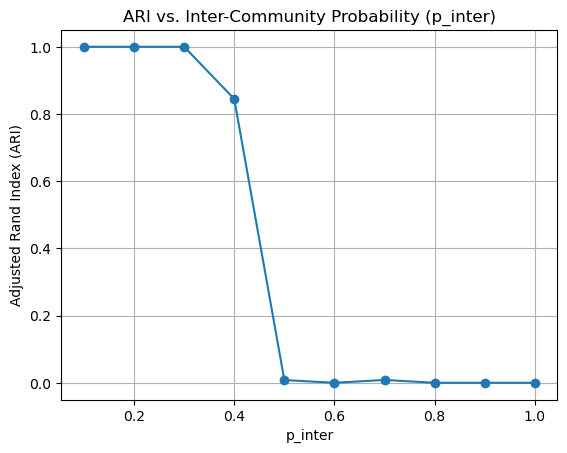

In [24]:
# Use this cell to explore your solution.

# Plot the ARI values
plt.plot([p/10 for p in range(1, 11)], task_2c_solution(), marker='o')
plt.xlabel('p_inter')
plt.ylabel('Adjusted Rand Index (ARI)')
plt.title('ARI vs. Inter-Community Probability (p_inter)')
plt.grid(True)

# Show the plot
plt.show()

In [25]:
print(f"Task {task_id} - AG tests")
stu_ans = task_2c_solution()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, list
), f"Task {task_id}: Your function should return a list. "

assert (
    len(stu_ans) == 10
), f"Task {task_id}: Your returned ndarray has an incorrect number of elements. "

assert all(
    isinstance(num, float) for num in stu_ans
), (
    f"Task {task_id}: Your returned list should be a list of floats "
)



Task 2c - AG tests
Task 2c - your answer:
[1.0, 1.0, 1.0, 0.8448326530612245, 0.008152440821137414, 0.0, 0.008450577605969345, 0.0, 0.0, 0.0]


# Task 2d

*Reflection question*: Can you explain the shape of the curve p_inter vs. ARI? Why does ARI go down as p_inter increases?

# Part 3: Configuration graph generation model

# Task 3a:
Zark Muckerberg just created a new social media network. There are 6 users on it. One with 4 friends, one with 3 friends, three with 2 friends, and one with 1 friend. Use the configuration graph generation model to create a graph that could represent this network with seed=42.

Note: You do not need to remove self loops or multi-edges. Simply run the configuration model.

In [26]:
task_id = '3a'


In [27]:

def task_3a_solution():
    degree_sequence = [4, 3, 2, 2, 2, 1]
    G = nx.configuration_model(degree_sequence, seed=42)

    return G


In [28]:
# Use this cell to explore your solution.

task_3a_solution()

In [29]:
print(f"Task {task_id} - AG tests")
stu_ans = task_3a_solution()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, nx.classes.graph.Graph
), f"Task {task_id}: Your function should return a graph of type nx.classes.graph.Graph. "




Task 3a - AG tests
Task 3a - your answer:
MultiGraph with 6 nodes and 7 edges


# Task 3b:

We are going to use the football game network for this question. Calculate the degree distribution of the network, and use the NetworkX configuration model to create a new graph with the same degree distribution with seed=42. The function below should return the new graph. 

Hint: You may find the `.degree()` function useful.

In [30]:
task_id = '3b'

import networkx as nx
import pandas as pd
from collections import Counter

G_football = nx.read_gml('assets/football.gml', label='id')



In [31]:
def task_3b_solution():
    degree_sequence = [i[1] for i in list(G_football.degree())]
    new_G = nx.configuration_model(degree_sequence, seed=42)

    

    return new_G

In [32]:
# Use this cell to explore your solution.

task_3b_solution()

In [33]:
print(f"Task {task_id} - AG tests")
stu_ans = task_3b_solution()

print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, nx.classes.multigraph.MultiGraph
), f"Task {task_id}: Your function should return an np.ndarray. "




Task 3b - AG tests
Task 3b - your answer:
MultiGraph with 115 nodes and 613 edges


# Task 3c (Ungraded):

In this question, we're going to compare the real-world network with the network you created based on the real-world network's degree distribution in the previous question. We're going to examine the following metrics:
```m
[
    "Clustering Coefficient",
    "Average Shortest Path Length",
    "Assortativity",
    "Density",
    "Number of Connected Components" ,
    "Average Degree",
    "Diameter",
    "Fraction of Nodes in Largest CC",
]
```

Which do you think will have changed? 

Return the names of the Metrics that you believe will have remained similar as a list of strings.

Note: This question is not graded, but you are encouraged to reflect on the answer to test your understanding of the Configuration Model. 


In [34]:
def task_3c():
    return [
        "Average Degree",
        "Density"
    ]

Now take a look at the metrics that remained the same. Were your guesses accurate? If not, why do you think that is?

In [35]:
def calculate_metrics(G):
    largest_cc = max(nx.connected_components(G), key=len)  # Find largest connected component
    G_lcc = G.subgraph(largest_cc)  # Subgraph of the largest connected component

    return {
        "Clustering Coefficient": nx.average_clustering(G),
        "Average Shortest Path Length": nx.average_shortest_path_length(G) if nx.is_connected(G) else float('inf'),
        "Assortativity": nx.degree_assortativity_coefficient(G),
        "Density": nx.density(G),
        "Number of Connected Components": nx.number_connected_components(G),        
        "Average Degree": sum(dict(G.degree()).values()) / G.number_of_nodes(),
        "Diameter": nx.diameter(G_lcc) if nx.is_connected(G_lcc) else float('inf'),
        "Fraction of Nodes in Largest CC": len(largest_cc) / G.number_of_nodes()
    }

def clean_graph(G):
    # Convert to simple graph (remove parallel edges and self-loops)
    G = nx.Graph(G)
    G.remove_edges_from(nx.selfloop_edges(G))
    return G

def print_metrics():
    G_football = nx.read_gml('assets/football.gml', label='id')
    new_G = task_3b_solution()

    # Clean both graphs in the same way to ensure fair comparison
    G_football_clean = clean_graph(G_football)
    new_G_clean = clean_graph(new_G)

    # Calculate metrics
    metrics_football = calculate_metrics(G_football_clean)
    metrics_config_model = calculate_metrics(new_G_clean)

    # Create DataFrame to compare metrics
    df = pd.DataFrame({
        "Metric": metrics_football.keys(),
        "G_football": metrics_football.values(),
        "Configuration Model": metrics_config_model.values()
    })

    return df

print_metrics()


,Metric,G_football,Configuration Model
0,Clustering Coefficient,0.403216,0.085071
1,Average Shortest Path Length,2.508162,2.284363
2,Assortativity,0.162442,0.102090
3,Density,0.093516,0.088940
4,Number of Connected Components,1.000000,1.000000
5,Average Degree,10.660870,10.139130
6,Diameter,4.000000,4.000000
7,Fraction of Nodes in Largest CC,1.000000,1.000000
